![hslu_logo.png](img/hslu_logo.png)

## Week 02

<hr style="border:1px solid black">

# Excercise: Multi-Layer-Perceptron using PyTorch
---
---
This excercise is to illustrate the representational capacity of a multi layer perceptrion through application on synthetic 2D-classification problems.

### Import necessary packages

In [89]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import math
import cv2

from utils import create_data, plot_img, plot_data

#### Test the creation of data

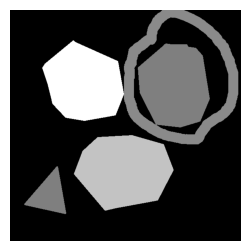

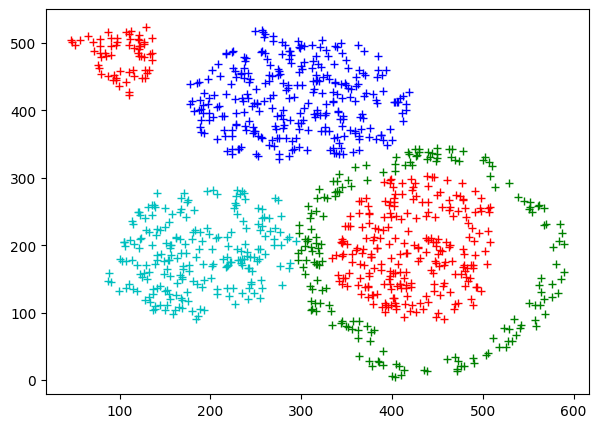

In [90]:
x,y,img = create_data(1000, imgName='Regions01.png')

plot_img(img)

plot_data(x,y)

#### Define the neural network

In [96]:
class MultiLayerPerceptron:
    """
    Multi layer Perceptron class doing the forward and backward step
    """
    def __init__(self, num_input, num_hidden, num_output):
        """
        constructor

        Arguments:
        num_input -- number of input values
        num_hidden -- number of hidden neurons
        num_output -- number of output values (categories)
        
        """
        self.model = torch.nn.Sequential(
            torch.nn.Linear(num_input, num_hidden),
            ### START YOUR CODE ###
            torch.nn.ReLU(),     # activation function of hidden layer
            torch.nn.Linear(num_hidden, num_output),  # output layer
            ### END YOUR CODE ###*
        )
                         
        self.cost_fn = torch.nn.CrossEntropyLoss(reduction='mean')
        
    def propagate(self, X):
        """
        calculates the function estimation based on current parameters [W,B]
        """    
        self.Y_pred = self.model(X)
           
     
    def back_propagate(self, cost):
        """
        calculates the backpropagation results based on expected output y
        this function must be performed AFTER the corresponding propagte step
        """    
        self.model.zero_grad()
        
        cost.backward()
 

    def calc_cost(self, Y):
        """
        calculates the MSE loss function
        """
        cost = self.cost_fn(self.Y_pred, Y)
        
        return cost
    
        
        
    def gradient_descend(self, alpha):
        """
        does the gradient descend based on results from last back_prop step with learning rate alpha
        """
        with torch.no_grad():
            for param in self.model.parameters():
                param -= alpha * param.grad
            
     
        
    def calc_error(self, Y):
        """
        get error information
        """
        m = Y.shape[0]

        Y_pred_argmax = torch.argmax(self.Y_pred, dim=1)
        train_error = torch.sum(Y != Y_pred_argmax) / m

        return train_error

        
        
    def optimize(self, data, epochs, alpha, debug=0):
        """
        performs epochs number of gradient descend steps and appends result to output array

        Arguments:
        data -- dictionary with data
        epochs -- number of epochs
        alpha -- learning rate
        debug -- False (default)/True; get info on each gradient descend step
        """
        
        # save results before 1st step
        for i0 in range(0, epochs):
            #do prediction
            self.propagate(data['X_train'])
            #determine the loss 
            cost = self.calc_cost(data['Y_train'])
            #determine the error
            self.back_propagate(cost)
            #do the correction step
            self.gradient_descend(alpha)
            #calculate the error
            error = self.calc_error(data['Y_train'])
            
            if debug and np.mod(i0, debug) == 0:
                print('step %r, cost %r, error %r' % (i0, cost.item(), error.item()))
                        
            

#### Create the data

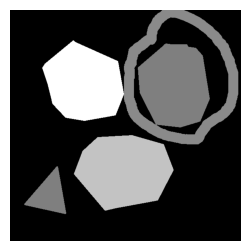

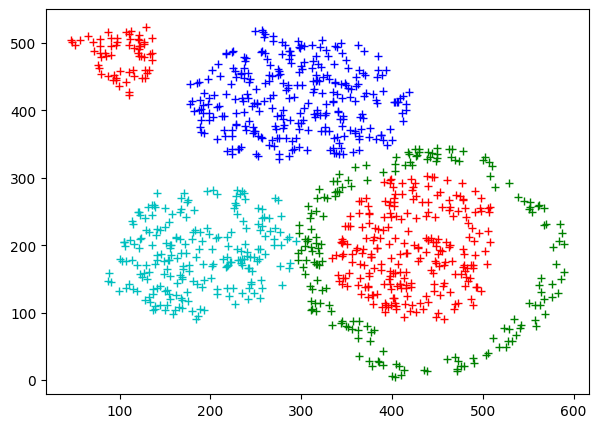

In [92]:
x,y,img = create_data(1000, imgName='Regions01.png')

plot_img(img)

plot_data(x,y)

#### Conversion to torch tensor and normalisation 

Training is more robust if the data is normalised such that all features have the same scale. Two typical schemes exist:
- min-max-rescaling:
  Data is scaled to interval $[0,1]$
- min-max-normalization
  Data is scaled to interval $[-1,1]$

Type conversion is also important because PyTorch is very strict on type compatibility!

In [93]:
#convert to tensor
data_X = torch.tensor(x, dtype=torch.float32)
data_Y = torch.tensor(y, dtype=torch.int64)

#normalize data: original data is overwritten
data_min, data_max = torch.min(data_X), torch.max(data_X)
print('original min-max values are: %r, %r and type %r' % (data_min.item(), data_max.item(), data_min.dtype))

normalize_tpye = 1

if normalize_tpye == 0:
    #min-max-rescaling
    data_X = (data_X - data_min) / (data_max - data_min)    
else:
    #min-max-normalization
    data_X = 2*(data_X - data_min) / (data_max - data_min) - 1

data_min, data_max = torch.min(data_X), torch.max(data_X)
print('now min-max values are: %r, %r and type %r' % (data_min.item(), data_max.item(), data_min.dtype))


original min-max values are: 5.029847621917725, 589.450439453125 and type torch.float32
now min-max values are: -1.0, 1.0 and type torch.float32


#### Setup Perceptron and do optimization

In [94]:
data = {'X_train' : data_X, 'Y_train' : data_Y}

num_input = data_X.shape[1]
num_output = len(torch.unique(data_Y))

num_hidden = 4

mlp = MultiLayerPerceptron(num_input, num_hidden, num_output)

print(mlp.model)

mlp.optimize(data, 400, 0.5, 50)


Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
)
step 0, cost 1.4333412647247314, error 0.6779999732971191


step 50, cost 0.7040742039680481, error 0.23600000143051147
step 100, cost 0.5217047929763794, error 0.20499999821186066
step 150, cost 0.4381263554096222, error 0.16300000250339508
step 200, cost 0.38335007429122925, error 0.13699999451637268
step 250, cost 0.34668055176734924, error 0.11800000071525574
step 300, cost 0.3218466639518738, error 0.11400000005960464
step 350, cost 0.34965214133262634, error 0.15800000727176666


#### Visualise the result

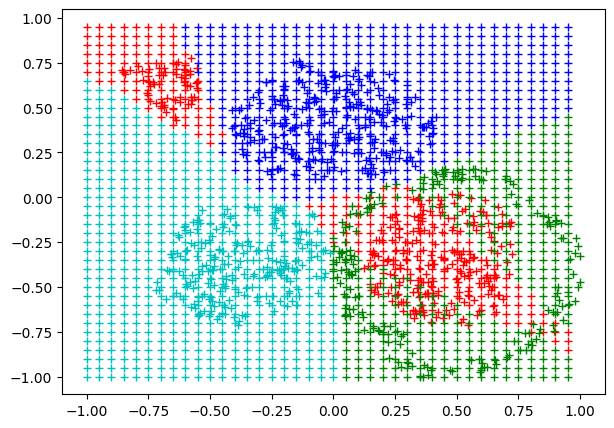

In [95]:
step = 0.05
grid = np.mgrid[-1.:1.:step,-1.:1.:step]

grid_points = grid.reshape(2,int(grid.size/2)).T

y_pred = torch.argmax(mlp.model(torch.tensor(grid_points, dtype=torch.float32)),1)
plot_data(np.append(grid_points, data['X_train'],axis=0), np.append(y_pred, data['Y_train']))
#plot_data(grid_points, y_pred_argmax)